#### Imports

In [199]:
import importlib
import matplotlib.pyplot as plt
import numpy as np
import copy
import random
import os
from pathlib import Path
import pandas as pd
import time
import itertools

from tqdm import tqdm
from collections import defaultdict
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
import pickle
from sklearn.model_selection import train_test_split

import globals
import utils

np.set_printoptions(precision=4, suppress=True, linewidth=np.inf, threshold=np.inf)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Current device:", device)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

Current device: cuda


In [200]:
importlib.reload(globals)
importlib.reload(utils)

<module 'utils' from 'c:\\Users\\Matteo\\Desktop\\Scuola\\MastersThesis\\Masters_Thesis\\utils.py'>

In [201]:
param_names, function_names = utils.inspect_metadata(globals.CURRENT_TRAIN_FILE)

Keys in train_file: ['I0', 'LUTdata', 'LUTheader', 'dynamic', 'static', 'wvl']

Attributes in LUTheader (inputs):
  varnames: O3STR,H2OSTR,VIS,G,ASTMX,SSA,PARM2,OBSZEN,PARM1

Attributes in train_file (outputs):
  RTMname: MODTRAN6
  inputmode: Latin hypercube
  lut_package_date: 10-Apr-2025
  opmode: Transfer Functions
  outnames: Lp0,Edir0,Edif0,S,tdir,tdif
  sensor: Empty(dtype=dtype('O'))

LUTheader shape: (500, 9)
LUTdata shape: (500, 25230)
wvl shape: (1, 4205)


In [202]:
param_names_plots = ['Ozone (atm-cm)', 'Columnar Water Vapor (g/cm^2)', 'Aerosol Optical Depth (-)', 'Asymmetry Parameter (-)', 'Angstrom Exponent (-)',
                     'Single Scattering Albedo (-)', 'Solar Zenith Angle (deg)', 'View Zenith Angle (deg)', 'Relative Azimuth Angle (deg)']
param_names_plots_abb = ['O3', 'CWV', 'AOD', 'Asy. Param.', 'Ang. Exp.', 'SSA', 'SZA', 'VZA', 'RAA']

function_names_plots = ['Path Radiance', 'Direct Solar Irradiance', 'Diffuse Solar Irradiance', 'Spherical Albedo', 'Direct Transmittance', 'Diffuse Transmittance']
function_names_plots_abb = ['Path Rad.', 'Direct Irrad.', 'Diffuse Irrad.', 'Sph. Alb.', 'Direct Trans.', 'Diffuse Trans.']

In [203]:
X, Y, wavelengths = utils.load_train_h5(globals.CURRENT_TRAIN_FILE)
wavelengths = wavelengths.squeeze()
Y_resh = Y.reshape(-1, Y.shape[1] // len(wavelengths), len(wavelengths))

# first split: train (80%) and temp (20%)
X_tr, X_temp, Y_tr, Y_temp = train_test_split(X, Y_resh, test_size=0.2, shuffle=True, random_state=42)

# second split: validation (10%) and test (10%)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, shuffle=True, random_state=42)

print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("wavelengths shape:", wavelengths.shape)
print()
print("X_tr shape:", X_tr.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print()
print("Y_tr shape:", Y_tr.shape)
print("Y_val shape:", Y_val.shape)
print("Y_test shape:", Y_test.shape)

X shape: (500, 9)
Y shape: (500, 25230)
wavelengths shape: (4205,)

X_tr shape: (400, 9)
X_val shape: (50, 9)
X_test shape: (50, 9)

Y_tr shape: (400, 6, 4205)
Y_val shape: (50, 6, 4205)
Y_test shape: (50, 6, 4205)


#### Convolutional Neural Network Pipeline

<ol>
    <li><b>Model and Dataset Definition</b>: Encoder-Decoder architecture.</li>
    <li><b>Training/Validation</b>: train loop with validation to choose the best model.</li>
    <li><b>External Testing</b> of the best selected model.</li>
</ol>

In [204]:
class Dataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

In [205]:
class Encoder(nn.Module):
    def __init__(self, z_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(9, 64),
            nn.SiLU(),
            nn.Linear(64, 128),
            nn.SiLU(),
            nn.Linear(128, z_dim),
            nn.SiLU()
        )

    def forward(self, x):
        return self.net(x)

In [206]:
# 1st ARCHITECTURE: upsample convolutions to reconstruct the full spectrum from a low-dimensional latent space calculated from the 9 inputs
class SpectralDecoder1(nn.Module):
    def __init__(self, z_dim=128, channels=64):
        super().__init__()
        self.fc = nn.Linear(z_dim, channels * 64)

        # processing at low-res (64 --> 64 length)
        self.initial_conv = nn.Sequential(
            nn.Conv1d(channels, 64, kernel_size=5, padding=2),
            nn.GroupNorm(8, 64),
            nn.SiLU()
        )

        # progressively upsample the sequence length
        # formula: Out = (In - 1) * stride - 2 * padding + kernel_size
        self.upsample_pipeline = nn.Sequential(
            # 64 -> 256 length
            nn.ConvTranspose1d(64, 32, kernel_size=6, stride=4, padding=1), 
            nn.GroupNorm(8, 32),
            nn.SiLU(),
            
            # 256 -> 1024 length
            nn.ConvTranspose1d(32, 16, kernel_size=6, stride=4, padding=1),
            nn.GroupNorm(4, 16),
            nn.SiLU(),

            # 1024 -> 4096 length
            nn.ConvTranspose1d(16, 8, kernel_size=6, stride=4, padding=1),
            nn.GroupNorm(2, 8),
            nn.SiLU()
        )

        # final adjustment to hit exactly 4205 and map to 1 output channel
        self.final_conv = nn.Conv1d(8, 1, kernel_size=5, padding=2)

    def forward(self, z):
        x = self.fc(z).view(z.size(0), 64, 64)
        x = self.initial_conv(x)
        x = self.upsample_pipeline(x) # shape is now (N, 8, 4096)
        
        # from 4096, use a tiny interpolation just to cover the last 109 points
        x = F.interpolate(x, size=4205, mode="linear", align_corners=False)
        
        x = self.final_conv(x).squeeze(1)
        return x
    
class EmulatorSet1(nn.Module):
    def __init__(self, encoder_type="single"):
        super().__init__()
        self.encoder_type = encoder_type
        if encoder_type == "single":
            self.encoder = Encoder()
        else:
            self.encoder = nn.ModuleList([
                Encoder() for _ in range(globals.N_FUNCTIONS)
            ])

        # 6 decoders, one for each radiative transfer function
        self.decoders = nn.ModuleList([
            SpectralDecoder1() for _ in range(globals.N_FUNCTIONS)
        ])

    def forward(self, x):
        if self.encoder_type == "single":
            z = self.encoder(x)
            outputs = [
                decoder(z)
                for decoder in self.decoders
            ]
        else:
            outputs = [
                decoder(encoder(x))
                for encoder, decoder in zip(self.encoder, self.decoders)
            ]
            
        # return prediction as one tensor of shape (N, 6, 4205)
        return torch.stack(outputs, dim=1)

In [207]:
# 2nd ARCHITECTURE: directly predict the PCA coefficients for each function from the latent space with MLP, without upsampling convolutions
class SpectralDecoder2(nn.Module):
    def __init__(self, z_dim=128, n_components=10):
        super().__init__()
        # map the latent space to the PCA coefficients
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.SiLU(),
            nn.Linear(256, 128),
            nn.SiLU(),
            nn.Linear(128, n_components) # output shape: (N, 10)
        )

    def forward(self, z):
        return self.net(z)

class EmulatorSet2(nn.Module):
    def __init__(self, encoder_type="single", n_components=10):
        super().__init__()
        self.encoder_type = encoder_type
        if encoder_type == "single":
            self.encoder = Encoder()
        else:
            self.encoder = nn.ModuleList([
                Encoder() for _ in range(globals.N_FUNCTIONS)
            ])
        
        self.decoders = nn.ModuleList([
            SpectralDecoder2(z_dim=128, n_components=n_components) for _ in range(globals.N_FUNCTIONS)
        ])

    def forward(self, x):
        if self.encoder_type == "single":
            z = self.encoder(x)
            outputs = [
                decoder(z)
                for decoder in self.decoders
            ]
        else:
            outputs = [
                decoder(encoder(x))
                for encoder, decoder in zip(self.encoder, self.decoders)
            ]
        # return prediction as one tensor of shape (N, 6, 10) - PCA coefficients for each function
        return torch.stack(outputs, dim=1)

In [208]:
# 3rd ARCHITECTURE: add convolutional processing to the latent space before predicting PCA coefficients, to allow the model to learn local relationships in the structured sequence space
# technically wrong, as the PCA-reduced space doesn't have a true spatial structure, but it allows us to experiment with convolutional processing
class SpectralDecoder3(nn.Module):
    def __init__(self, z_dim=128, n_components=10, initial_length=128, channels=64):
        super().__init__()
        self.initial_length = initial_length
        self.channels = channels

        # map latent space to a structured sequence space (64 channels x 128 length)
        self.fc = nn.Linear(z_dim, channels * initial_length)

        # convolutions process features across the sequence dimension
        self.cnn = nn.Sequential(
            nn.Conv1d(channels, 64, kernel_size=5, padding=2),
            nn.GroupNorm(8, 64),
            nn.SiLU(),
            nn.Conv1d(64, 32, kernel_size=5, padding=2),
            nn.GroupNorm(8, 32),
            nn.SiLU(),
            nn.Conv1d(32, 16, kernel_size=5, padding=2),
            nn.GroupNorm(4, 16),
            nn.SiLU(),
        )

        # collapse the remaining sequence length down to exactly our 10 PCA dimensions
        # total flattened size: 16 channels * 128 length = 2048 features
        self.to_pca = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * initial_length, 256),
            nn.SiLU(),
            nn.Linear(256, n_components) # final output shape: (N, 10)
        )

    def forward(self, z):
        # shape transition: (N, 128) -> (N, 64 * 128)
        x = self.fc(z)
        
        # reshape to 1D CNN format: (N, 64, 128)
        x = x.view(z.size(0), self.channels, self.initial_length)
        
        # convolutions process local relationships: (N, 16, 128)
        x = self.cnn(x)
        
        # flatten and project to the 10 PCA components: (N, 10)
        pca_coefficients = self.to_pca(x)
        return pca_coefficients
    
class EmulatorSet3(nn.Module):
    def __init__(self, encoder_type=True, n_components=10):
        super().__init__()
        self.encoder_type = encoder_type
        if encoder_type == "single":
            self.encoder = Encoder()
        else:
            self.encoder = nn.ModuleList([
                Encoder() for _ in range(globals.N_FUNCTIONS)
            ])
        
        self.decoders = nn.ModuleList([
            SpectralDecoder3(z_dim=128, n_components=n_components, initial_length=128, channels=64) 
            for _ in range(globals.N_FUNCTIONS)
        ])

    def forward(self, x):
        if self.encoder_type == "single":
            z = self.encoder(x)
            outputs = [
                decoder(z)
                for decoder in self.decoders
            ]
        else:
            outputs = [
                decoder(encoder(x))
                for encoder, decoder in zip(self.encoder, self.decoders)
            ]
        # return prediction as one tensor of shape (N, 6, 10) - PCA coefficients for each function
        return torch.stack(outputs, dim=1)

In [159]:
# 4th ARCHITECTURE: use squeeze and excite blocks to allow the model to learn which latent features are most important for each function, before predicting PCA coefficients
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()

        self.fc = nn.Sequential(
            nn.Linear(channels, channels // reduction),
            nn.SiLU(),
            nn.Linear(channels // reduction, channels),
            nn.Sigmoid()
        )

    def forward(self, x):
        weights = self.fc(x)
        return x * weights
    
class SpectralDecoder4(nn.Module):
    def __init__(self, z_dim=128, n_components=10):
        super().__init__()

        self.se = SEBlock(z_dim)

        self.mlp = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.SiLU(),
            nn.Linear(256, 128),
            nn.SiLU(),
            nn.Linear(128, n_components)
        )

    def forward(self, z):
        z = self.se(z)
        return self.mlp(z)
    
class EmulatorSet4(nn.Module):
    def __init__(self, encoder_type="single", n_components=10):
        super().__init__()

        self.encoder_type = encoder_type
        if encoder_type == "single":
            self.encoder = Encoder()
        else:
            self.encoder = nn.ModuleList([
                Encoder() for _ in range(globals.N_FUNCTIONS)
            ])

        self.decoders = nn.ModuleList([
            SpectralDecoder4(z_dim=128, n_components=n_components)
            for _ in range(globals.N_FUNCTIONS)
        ])

    def forward(self, x):
        if self.encoder_type == "single":
            z = self.encoder(x)
            outputs = [
                decoder(z)
                for decoder in self.decoders
            ]
        else:
            outputs = [
                decoder(encoder(x))
                for encoder, decoder in zip(self.encoder, self.decoders)
            ]

        return torch.stack(outputs, dim=1)

In [160]:
# quick model test
model = EmulatorSet1(encoder_type="single").to(device)
model.eval()

# dummy input: (batch_size, 9)
X_tr_tensor = torch.tensor(X_tr, dtype=torch.float32).to(device)
print("Input shape:", X_tr_tensor.shape)

with torch.no_grad():
    y_pred = model(X_tr_tensor)

# y is a tensor of shape (N, 6, 4205)
print("Output shape:", y_pred.shape)

summary(model, input_size=(1, globals.N_INPUTS))

Input shape: torch.Size([400, 9])
Output shape: torch.Size([400, 6, 4205])
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                [-1, 1, 64]             640
              SiLU-2                [-1, 1, 64]               0
            Linear-3               [-1, 1, 128]           8,320
              SiLU-4               [-1, 1, 128]               0
            Linear-5               [-1, 1, 128]          16,512
              SiLU-6               [-1, 1, 128]               0
           Encoder-7               [-1, 1, 128]               0
            Linear-8              [-1, 1, 4096]         528,384
            Conv1d-9               [-1, 64, 64]          20,544
        GroupNorm-10               [-1, 64, 64]             128
             SiLU-11               [-1, 64, 64]               0
  ConvTranspose1d-12              [-1, 32, 256]          12,320
        GroupNorm-13        

Reduce and scale to prepare the datasets.

In [161]:
# # scaled inputs
# scale_type = "minmax"
# x_scaler, X_tr_scaled, X_val_scaled = utils.scale_input_data(X_tr, X_val, scale_type=scale_type)

# # scaled outputs
# y_scalers, Y_tr_scaled, Y_val_scaled = utils.scale_output_data(Y_tr, Y_val, scale_type=scale_type)

# # PCA-reduced outputs
# pca_list, Y_tr_reduced, Y_val_reduced = utils.apply_pca(Y_tr, Y_val, n_components=10)

# # scaled and PCA-reduced outputs
# y_scalers_reduced, Y_tr_reduced_scaled, Y_val_reduced_scaled = utils.scale_output_data(Y_tr_reduced, Y_val_reduced, scale_type=scale_type)

# # prepare test set with the same transformations
# X_test_scaled = x_scaler.transform(X_test)
# Y_test_scaled = np.zeros_like(Y_test)
# Y_test_reduced = np.zeros((Y_test.shape[0], globals.N_FUNCTIONS, 10))
# Y_test_reduced_scaled = np.zeros((Y_test.shape[0], globals.N_FUNCTIONS, 10))

# for i in range(globals.N_FUNCTIONS):
#     Y_test_scaled[:, i, :] = y_scalers[i].transform(Y_test[:, i, :])

# for i in range(globals.N_FUNCTIONS):
#     Y_test_reduced[:, i, :] = pca_list[i].transform(Y_test[:, i, :])
#     Y_test_reduced_scaled[:, i, :] = y_scalers_reduced[i].transform(Y_test_reduced[:, i, :])

In [162]:
# print("Train scaled min:", Y_tr_scaled.min())
# print("Val scaled min:", Y_val_scaled.min())

# print(np.sum(Y_tr_scaled == 0))
# print(np.sum(Y_val_scaled == 0))

Using MRE as the loss function in this scenario would not be desirable, as the training loss would explode to very high values due to the high amount of training values near zero. Scaled or reduced data has many values that are zero or near zero, which would make the MRE explode. Using a wavelength mask would exclude deep absorption bands, but the MRE would still be calculated on the scaled and reduced data, which would not solve the exploding problem. MRE calculated on the restored data could be used as loss, but it would not be a meaningful objective, as it would be calculated on data that is fundamentally different from what the model actually sees.

In [ ]:
def create_datasets(X_tr, X_val, Y_tr, Y_val, X_test, Y_test, verbose=True):
    train_ds = Dataset(X_tr, Y_tr)
    val_ds = Dataset(X_val, Y_val)
    test_ds = Dataset(X_test, Y_test)

    if verbose:
        print("Train dataset length:", len(train_ds))
        print("Val dataset length:", len(val_ds))
        print("Test dataset length:", len(test_ds))

        # get item check
        x, y = train_ds.__getitem__(0)
        print("Input shape:", x.shape)
        print("Output shape:", y.shape)
        print()

    return train_ds, val_ds, test_ds

In [164]:
# # unscaled and non-reduced version
# train_ds, val_ds, test_ds = create_datasets(X_tr, X_val, Y_tr, Y_val, X_test, Y_test)

# # scaled and non-reduced version
# train_ds_scaled, val_ds_scaled, test_ds_scaled = create_datasets(X_tr_scaled, X_val_scaled, Y_tr_scaled, Y_val_scaled, X_test_scaled, Y_test_scaled)

# # unscaled and PCA-reduced version
# train_ds_reduced, val_ds_reduced, test_ds_reduced = create_datasets(X_tr, X_val, Y_tr_reduced, Y_val_reduced, X_test, Y_test_reduced)

# # scaled and PCA-reduced version
# train_ds_reduced_scaled, val_ds_reduced_scaled, test_ds_reduced_scaled = create_datasets(X_tr_scaled, X_val_scaled, Y_tr_reduced_scaled, Y_val_reduced_scaled, X_test_scaled, Y_test_reduced_scaled)

In [165]:
SCALE_TYPES = [
    "minmax", 
    "standard",
]

def prepare_all_experiments(X_tr, X_val, X_test, Y_tr, Y_val, Y_test, n_pca_components=10):
    config = {
        "x_scalers":               {},
        "y_scalers":               {},
        "y_scalers_reduced":       {},
        "pca_lists":               {},
        "train_ds_scaled":         {},
        "val_ds_scaled":           {},
        "test_ds_scaled":          {},
        "train_ds_reduced_scaled": {},
        "val_ds_reduced_scaled":   {},
        "test_ds_reduced_scaled":  {},
    }

    # PCA is fit on raw outputs — independent of scale type, so compute once
    pca_list, Y_tr_reduced, Y_val_reduced = utils.apply_pca(Y_tr, Y_val, n_components=n_pca_components)
    Y_test_reduced = np.zeros((Y_test.shape[0], globals.N_FUNCTIONS, n_pca_components))
    for i in range(globals.N_FUNCTIONS):
        Y_test_reduced[:, i, :] = pca_list[i].transform(Y_test[:, i, :])

    for scale_type in SCALE_TYPES:
        print(f"\n── Preparing [{scale_type}] ──────────────────────────────")

        # --- inputs ---
        x_scaler, X_tr_scaled, X_val_scaled = utils.scale_input_data(
            X_tr, X_val, scale_type=scale_type
        )
        X_test_scaled = x_scaler.transform(X_test)

        # --- full outputs ---
        y_scalers, Y_tr_scaled, Y_val_scaled = utils.scale_output_data(
            Y_tr, Y_val, scale_type=scale_type
        )
        Y_test_scaled = np.zeros_like(Y_test)
        for i in range(globals.N_FUNCTIONS):
            Y_test_scaled[:, i, :] = y_scalers[i].transform(Y_test[:, i, :])

        # --- reduced outputs ---
        y_scalers_reduced, Y_tr_reduced_scaled, Y_val_reduced_scaled = utils.scale_output_data(
            Y_tr_reduced, Y_val_reduced, scale_type=scale_type
        )
        Y_test_reduced_scaled = np.zeros((Y_test.shape[0], globals.N_FUNCTIONS, n_pca_components))
        for i in range(globals.N_FUNCTIONS):
            Y_test_reduced_scaled[:, i, :] = y_scalers_reduced[i].transform(Y_test_reduced[:, i, :])

        # --- datasets ---
        train_ds_scaled, val_ds_scaled, test_ds_scaled = create_datasets(
            X_tr_scaled, X_val_scaled, Y_tr_scaled, Y_val_scaled, X_test_scaled, Y_test_scaled
        )
        train_ds_reduced_scaled, val_ds_reduced_scaled, test_ds_reduced_scaled = create_datasets(
            X_tr_scaled, X_val_scaled, Y_tr_reduced_scaled, Y_val_reduced_scaled,
            X_test_scaled, Y_test_reduced_scaled
        )

        # --- store everything under the scale_type key ---
        config["x_scalers"][scale_type]               = x_scaler
        config["y_scalers"][scale_type]               = y_scalers
        config["y_scalers_reduced"][scale_type]       = y_scalers_reduced
        config["pca_lists"][scale_type]               = pca_list        # same for both
        config["train_ds_scaled"][scale_type]         = train_ds_scaled
        config["val_ds_scaled"][scale_type]           = val_ds_scaled
        config["test_ds_scaled"][scale_type]          = test_ds_scaled
        config["train_ds_reduced_scaled"][scale_type] = train_ds_reduced_scaled
        config["val_ds_reduced_scaled"][scale_type]   = val_ds_reduced_scaled
        config["test_ds_reduced_scaled"][scale_type]  = test_ds_reduced_scaled

    # training hyperparameters
    config["batch_size"] = 4
    config["n_epochs"]   = 100
    config["patience"]   = 25

    return config

In [166]:
# ==================== EXPERIMENT GRID ====================
ARCHITECTURES = {
    "EmulatorSet1": EmulatorSet1,
    "EmulatorSet2": EmulatorSet2,
    "EmulatorSet3": EmulatorSet3,
    "EmulatorSet4": EmulatorSet4,
}

ENCODER_VERSIONS = [
    "single", 
    "multi",
]

# which model families use the full dataset vs. the reduced one
FULL_DS_MODELS    = {"EmulatorSet1"}
REDUCED_DS_MODELS = {"EmulatorSet2", "EmulatorSet3", "EmulatorSet4"}

config = prepare_all_experiments(X_tr, X_val, X_test, Y_tr, Y_val, Y_test)


# ==================== DATASET / SCALER ROUTER ====================
def get_loaders_and_scalers(model_name, scale_type, config):
    """Return (train_dl, val_dl, y_scalers) for a given experiment."""
    if model_name in FULL_DS_MODELS:
        train_ds = config["train_ds_scaled"][scale_type]
        val_ds   = config["val_ds_scaled"][scale_type]
        y_scalers = config["y_scalers"][scale_type]
        pca_list = None
    else:
        train_ds = config["train_ds_reduced_scaled"][scale_type]
        val_ds   = config["val_ds_reduced_scaled"][scale_type]
        y_scalers = config["y_scalers_reduced"][scale_type]
        pca_list = config["pca_lists"][scale_type]

    train_dl = torch.utils.data.DataLoader(train_ds, batch_size=config["batch_size"], shuffle=True)
    val_dl   = torch.utils.data.DataLoader(val_ds,   batch_size=config["batch_size"], shuffle=False)
    return train_ds, val_ds, train_dl, val_dl, y_scalers, pca_list


def calculate_metrics(y_pred, Y_batch, wavelengths, y_scalers, pca_list):
    is_scaled  = y_scalers is not None
    is_reduced = pca_list  is not None

    if is_scaled or is_reduced:
        # prepare tensors to hold the restored predictions and targets in original space
        y_pred_og_shape = torch.zeros((y_pred.size(0), globals.N_FUNCTIONS, len(wavelengths)), device=y_pred.device)
        y_true_og_shape = torch.zeros((Y_batch.size(0), globals.N_FUNCTIONS, len(wavelengths)), device=Y_batch.device)

        # inverse transform the scaling and PCA to get back to original space if needed
        for i in range(globals.N_FUNCTIONS):
            y_pred_restored = y_pred[:, i, :].cpu().detach().numpy()
            y_true_restored = Y_batch[:, i, :].cpu().detach().numpy()
            if is_scaled:
                y_pred_restored = y_scalers[i].inverse_transform(y_pred_restored)
                y_true_restored = y_scalers[i].inverse_transform(y_true_restored)
            if is_reduced:
                y_pred_restored = pca_list[i].inverse_transform(y_pred_restored)
                y_true_restored = pca_list[i].inverse_transform(y_true_restored)
            y_pred_og_shape[:, i, :] = torch.from_numpy(y_pred_restored).to(y_pred_og_shape.device)
            y_true_og_shape[:, i, :] = torch.from_numpy(y_true_restored).to(y_true_og_shape.device)

        batch_train_mre_unscaled = utils.mre_score(y_pred_og_shape.cpu().detach().numpy(), y_true_og_shape.cpu().detach().numpy(), wavelengths)
        batch_train_mae_unscaled = utils.mae_score(y_pred_og_shape.cpu().detach().numpy(), y_true_og_shape.cpu().detach().numpy(), wavelengths)
    else:
        batch_train_mre_unscaled = utils.mre_score(y_pred.cpu().detach().numpy(), Y_batch.cpu().detach().numpy(), wavelengths)
        batch_train_mae_unscaled = utils.mae_score(y_pred.cpu().detach().numpy(), Y_batch.cpu().detach().numpy(), wavelengths)

    return batch_train_mre_unscaled, batch_train_mae_unscaled


# ==================== SINGLE EXPERIMENT ====================
def run_experiment(model_name, encoder_version, scale_type, config, device, wavelengths):
    exp_id = f"{model_name}_{encoder_version}_{scale_type}"
    print(f"\n{'='*60}")
    print(f"  EXPERIMENT: {exp_id}")
    print(f"{'='*60}")

    # --- build model ---
    ModelClass = ARCHITECTURES[model_name]
    model = ModelClass(encoder_type=encoder_version).to(device)

    # --- data ---
    train_ds, val_ds, train_dl, val_dl, y_scalers, pca_list = get_loaders_and_scalers(
        model_name, scale_type, config
    )

    # --- optimiser / loss / scheduler ---
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = torch.nn.L1Loss()
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.2, patience=5
    )

    # --- early stopping state ---
    n_epochs        = config.get("n_epochs", 100)
    patience        = config.get("patience", 25)
    best_val_mre    = float("inf")
    patience_counter = 0
    best_model_wts  = copy.deepcopy(model.state_dict())
    history         = defaultdict(list)

    start_time = time.time()

    for epoch in range(n_epochs):
        # ---------- TRAIN ----------
        model.train()
        epoch_train_loss = epoch_train_mre = epoch_train_mae = 0.0

        for X_batch, Y_batch in tqdm(train_dl, desc=f"[{exp_id}] E{epoch+1} Train", leave=False):
            X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss   = criterion(y_pred, Y_batch)
            loss.backward()
            optimizer.step()

            mre, mae = calculate_metrics(y_pred, Y_batch, wavelengths, y_scalers, pca_list)
            n = X_batch.size(0)
            epoch_train_loss += loss.item() * n
            epoch_train_mre  += mre * n
            epoch_train_mae  += mae * n

        n_train = len(train_ds)
        epoch_train_loss /= n_train
        epoch_train_mre  /= n_train
        epoch_train_mae  /= n_train

        # ---------- VALIDATE ----------
        model.eval()
        epoch_val_loss = epoch_val_mre = epoch_val_mae = 0.0

        with torch.no_grad():
            for X_batch, Y_batch in tqdm(val_dl, desc=f"[{exp_id}] E{epoch+1} Val", leave=False):
                X_batch, Y_batch = X_batch.to(device), Y_batch.to(device)
                y_pred = model(X_batch)
                loss   = criterion(y_pred, Y_batch)

                mre, mae = calculate_metrics(y_pred, Y_batch, wavelengths, y_scalers, pca_list)
                n = X_batch.size(0)
                epoch_val_loss += loss.item() * n
                epoch_val_mre  += mre * n
                epoch_val_mae  += mae * n

        n_val = len(val_ds)
        epoch_val_loss /= n_val
        epoch_val_mre  /= n_val
        epoch_val_mae  /= n_val

        scheduler.step(epoch_val_loss)

        # record
        history["train_loss"].append(epoch_train_loss)
        history["train_mre"].append(epoch_train_mre)
        history["train_mae"].append(epoch_train_mae)
        history["val_loss"].append(epoch_val_loss)
        history["val_mre"].append(epoch_val_mre)
        history["val_mae"].append(epoch_val_mae)

        print(
            f"  E{epoch+1:03d} | "
            f"train loss {epoch_train_loss:.5f}  mre {epoch_train_mre:.5f}  mae {epoch_train_mae:.5f} | "
            f"val loss {epoch_val_loss:.5f}  mre {epoch_val_mre:.5f}  mae {epoch_val_mae:.5f}"
        )

        # ---------- EARLY STOPPING ----------
        if epoch_val_mre < best_val_mre:
            best_val_mre   = epoch_val_mre
            best_model_wts = copy.deepcopy(model.state_dict())
            patience_counter = 0
            print("  --> best val MRE — weights saved")
        else:
            patience_counter += 1
            print(f"  --> no improvement ({patience_counter}/{patience})")
            if patience_counter >= patience:
                print("  !!! early stopping !!!")
                break

    elapsed = time.time() - start_time

    # reload best weights
    model.load_state_dict(best_model_wts)

    # persist model
    os.makedirs("nn_results", exist_ok=True)
    torch.save(model.state_dict(), f"nn_results/{exp_id}.pth")

    # save history
    with open(f"nn_results/{exp_id}_history.pkl", "wb") as f:
        pickle.dump(history, f)

    # build result row
    idx_best = int(np.argmin(history["val_mre"]))
    result = {
        "experiment_id":  exp_id,
        "model":          model_name,
        "encoder":        encoder_version,
        "scale_type":     scale_type,
        "fit_time":       elapsed,
        "best_epoch":     idx_best + 1,
        "best_train_loss": history["train_loss"][idx_best],
        "best_val_loss":   history["val_loss"][idx_best],
        "best_train_mre":  history["train_mre"][idx_best],
        "best_val_mre":    history["val_mre"][idx_best],
        "best_train_mae":  history["train_mae"][idx_best],
        "best_val_mae":    history["val_mae"][idx_best],
    }
    return model, history, result


# ==================== FULL EXPERIMENT LOOP ====================
def run_all_experiments(config, device, wavelengths):
    results_path = Path("nn_results/nn_results.csv")
    all_results  = []

    grid = list(itertools.product(ARCHITECTURES.keys(), ENCODER_VERSIONS, SCALE_TYPES))
    print(f"Total experiments to run: {len(grid)}")

    for model_name, encoder_version, scale_type in grid:
        try:
            model, history, result = run_experiment(
                model_name, encoder_version, scale_type,
                config, device, wavelengths
            )
            all_results.append(result)

            # append to CSV after every experiment so a crash doesn't lose data
            row_df = pd.DataFrame([result])
            row_df.to_csv(
                results_path,
                mode="a",
                header=not results_path.exists(),
                index=False,
            )
            print(f"  Saved results for {result['experiment_id']}\n")

        except Exception as e:
            print(f"  [ERROR] {model_name}__{encoder_version}__{scale_type} failed: {e}")
            continue

    summary = pd.DataFrame(all_results).sort_values("best_val_mre")
    print("\n===== EXPERIMENT SUMMARY (sorted by val MRE) =====")
    print(summary[["experiment_id", "best_val_mre", "best_val_mae", "best_epoch", "fit_time"]].to_string(index=False))
    return summary, model, history

---------- Applying PCA with n_components=10 to each function separately... ----------
  Regular PCA used, displaying results:
  Function 1: Explained variance = 1.0000
  Number of components retained: 10

  Function 2: Explained variance = 1.0000
  Number of components retained: 10

  Function 3: Explained variance = 1.0000
  Number of components retained: 10

  Function 4: Explained variance = 0.9999
  Number of components retained: 10

  Function 5: Explained variance = 1.0000
  Number of components retained: 10

  Function 6: Explained variance = 1.0000
  Number of components retained: 10

  Total explained variance = 5.9999
---------- PCA application completed. ----------


── Preparing [minmax] ──────────────────────────────
---------- Scaling input data using minmax scaling... ----------
---------- Input data scaling completed. ----------

---------- Scaling output data using minmax scaling... ----------
---------- Output data scaling completed. ----------

---------- Scaling ou

In [167]:
summary, model, history = run_all_experiments(config, device, wavelengths)

Total experiments to run: 16

  EXPERIMENT: EmulatorSet1_single_minmax


  E001 | train loss 0.17794  mre 0.27059  mae 30.17044 | val loss 0.09329  mre 0.09550  mae 15.75957
  --> best val MRE — weights saved


  E002 | train loss 0.06560  mre 0.06596  mae 10.64243 | val loss 0.05542  mre 0.05602  mae 8.13514
  --> best val MRE — weights saved


  E003 | train loss 0.04474  mre 0.04455  mae 7.13197 | val loss 0.04042  mre 0.04518  mae 5.74735
  --> best val MRE — weights saved


  E004 | train loss 0.03838  mre 0.04193  mae 6.08683 | val loss 0.04245  mre 0.04026  mae 8.29724
  --> best val MRE — weights saved


...

  E096 | train loss 0.02484  mre 0.00262  mae 0.31967 | val loss 0.04420  mre 0.00464  mae 0.57671
  --> best val MRE — weights saved


  E097 | train loss 0.02483  mre 0.00260  mae 0.31506 | val loss 0.04415  mre 0.00462  mae 0.56986
  --> best val MRE — weights saved


  E098 | train loss 0.02478  mre 0.00259  mae 0.31424 | val loss 0.04421  mre 0.00464  mae 0.57952
  --> no improvement (1/25)


  E099 | train loss 0.02476  mre 0.00259  mae 0.31278 | val loss 0.04414  mre 0.00466  mae 0.58209
  --> no improvement (2/25)


  E100 | train loss 0.02473  mre 0.00260  mae 0.31384 | val loss 0.04425  mre 0.00464  mae 0.57638
  --> no improvement (3/25)
  Saved results for EmulatorSet4_multi_standard


===== EXPERIMENT SUMMARY (sorted by val MRE) =====
               experiment_id  best_val_mre  best_val_mae  best_epoch   fit_time
 EmulatorSet4_multi_standard      0.004616      0.569857          97 135.151216
EmulatorSet2_single_standard      0.005032      0.577201          84  81.195236
 EmulatorSet2_multi_standard      0.005045      0.656122          96 103.342168
  EmulatorSet2_single_minmax      0.005361      0.606584          88  81.576405
EmulatorSet4_single_standard      0.005512      0.580087          65 103.147000
   EmulatorSet4_multi_minmax      0.005563      0.570635          97 136.105670
   EmulatorSet2_multi_minmax      0.005672      0.743132         100 100.643819
  EmulatorSet4_single_minmax      0.005868      0.615506          96 111.910448
 EmulatorSet1_multi_standard      0.005902      0.64

In [168]:
summary

,experiment_id,model,encoder,scale_type,fit_time,best_epoch,best_train_loss,best_val_loss,best_train_mre,best_val_mre,best_train_mae,best_val_mae
15,EmulatorSet4_multi_standard,EmulatorSet4,multi,standard,135.151216,97,0.024827,0.044154,0.002597,0.004616,0.315058,0.569857
5,EmulatorSet2_single_standard,EmulatorSet2,single,standard,81.195236,84,0.028716,0.046930,0.003072,0.005032,0.374951,0.577201
7,EmulatorSet2_multi_standard,EmulatorSet2,multi,standard,103.342168,96,0.025811,0.045376,0.002816,0.005045,0.360263,0.656122
4,EmulatorSet2_single_minmax,EmulatorSet2,single,minmax,81.576405,88,0.006406,0.008421,0.003849,0.005361,0.446636,0.606584
13,EmulatorSet4_single_standard,EmulatorSet4,single,standard,103.147000,65,0.031064,0.050314,0.003411,0.005512,0.419517,0.580087
14,EmulatorSet4_multi_minmax,EmulatorSet4,multi,minmax,136.105670,97,0.005843,0.007653,0.003949,0.005563,0.487139,0.570635
6,EmulatorSet2_multi_minmax,EmulatorSet2,multi,minmax,100.643819,100,0.007094,0.008645,0.004589,0.005672,0.567685,0.743132
12,EmulatorSet4_single_minmax,EmulatorSet4,single,minmax,111.910448,96,0.006009,0.008079,0.003887,0.005868,0.441183,0.615506
3,EmulatorSet1_multi_standard,EmulatorSet1,multi,standard,179.780565,98,0.029634,0.032828,0.004766,0.005902,0.481440,0.644724
1,EmulatorSet1_single_standard,EmulatorSet1,single,standard,166.915468,96,0.032435,0.037149,0.005209,0.006839,0.524602,0.726092


In [ ]:
# best model row load
results_df = pd.read_csv("nn_results/nn_results.csv")
best_model = results_df.loc[results_df["best_val_mre"].idxmin()]
print(best_model)

experiment_id      EmulatorSet4_multi_standard
model                             EmulatorSet4
encoder                                  multi
scale_type                            standard
fit_time                            135.151216
best_epoch                                  97
best_train_loss                       0.024827
best_val_loss                         0.044154
best_train_mre                        0.002597
best_val_mre                          0.004616
best_train_mae                        0.315058
best_val_mae                          0.569857
Name: 15, dtype: object


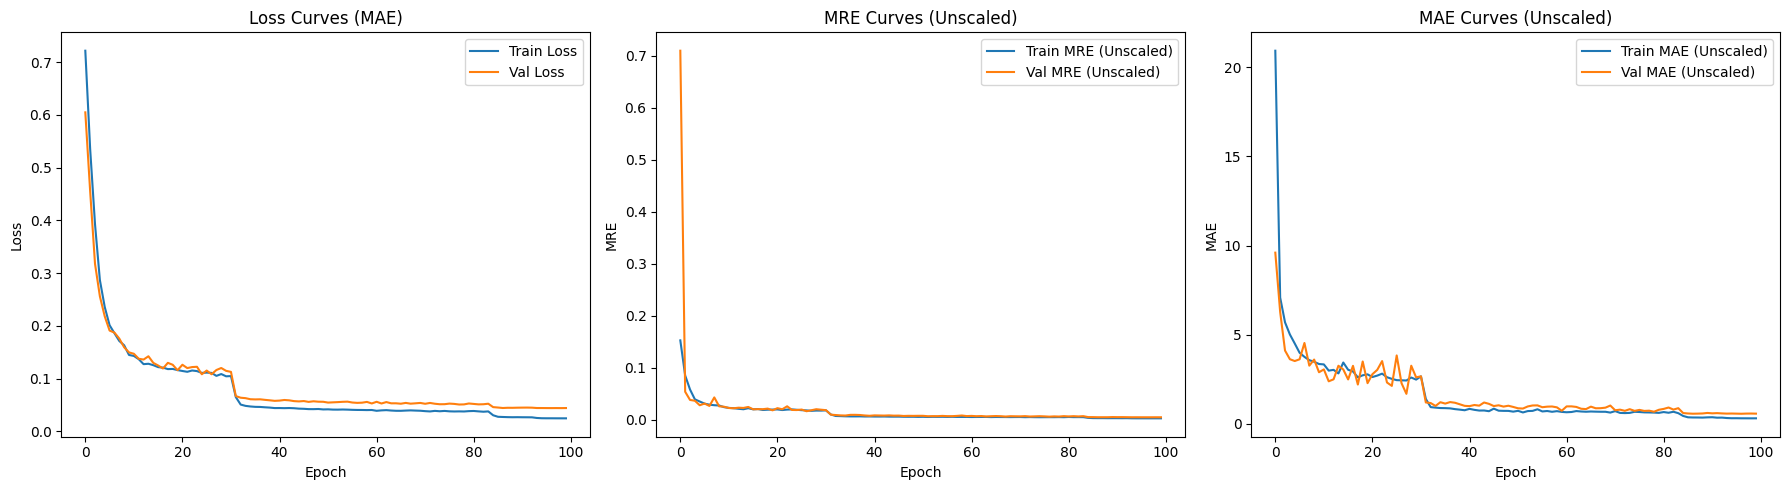

In [228]:
# history load
with open(f"nn_results/{best_model['experiment_id']}_history.pkl", "rb") as f:
    history = pickle.load(f)

# history plotting
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.title("Loss Curves (MAE)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history["train_mre"], label="Train MRE (Unscaled)")
plt.plot(history["val_mre"], label="Val MRE (Unscaled)")
plt.title("MRE Curves (Unscaled)")
plt.xlabel("Epoch")
plt.ylabel("MRE")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history["train_mae"], label="Train MAE (Unscaled)")
plt.plot(history["val_mae"], label="Val MAE (Unscaled)")
plt.title("MAE Curves (Unscaled)")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# load best model
model = ARCHITECTURES[best_model["model"]](encoder_type=best_model["encoder"]).to(device)
model.load_state_dict(torch.load(f"nn_results/{best_model['experiment_id']}.pth", map_location=device))

if best_model["model"] in FULL_DS_MODELS:
    test_ds = config["test_ds_scaled"][best_model["scale_type"]]
    y_scalers = config["y_scalers"][best_model["scale_type"]]
    pca_list = None
else:
    test_ds = config["test_ds_reduced_scaled"][best_model["scale_type"]]
    y_scalers = config["y_scalers_reduced"][best_model["scale_type"]]
    pca_list = config["pca_lists"][best_model["scale_type"]]
test_dl   = torch.utils.data.DataLoader(test_ds, batch_size=config["batch_size"], shuffle=False)
criterion = nn.L1Loss()

# test on test set
model.eval()
test_loss = 0.0
test_mre_unscaled = 0.0
test_mae_unscaled = 0.0
test_tqdm = tqdm(test_dl, desc="Testing")
with torch.no_grad():
    for X_batch, Y_batch in test_tqdm:
        X_batch = X_batch.to(device)
        Y_batch = Y_batch.to(device)

        y_pred = model(X_batch)
        
        loss = 0.0
        batch_test_mre_unscaled = 0.0
        batch_test_mae_unscaled = 0.0

        loss += criterion(y_pred, Y_batch)
        batch_test_mre_unscaled_partial, batch_test_mae_unscaled_partial = calculate_metrics(y_pred, Y_batch, wavelengths, y_scalers, pca_list)

        batch_test_mre_unscaled += batch_test_mre_unscaled_partial
        batch_test_mae_unscaled += batch_test_mae_unscaled_partial
            
        test_loss += loss.item() * X_batch.size(0)
        test_mre_unscaled += batch_test_mre_unscaled * X_batch.size(0)
        test_mae_unscaled += batch_test_mae_unscaled * X_batch.size(0)
        
        test_tqdm.set_postfix({
            "loss": loss.item(),
            "mre_unscaled": batch_test_mre_unscaled,
            "mae_unscaled": batch_test_mae_unscaled,
        })
        
print(f"\nFinal Test Loss: {test_loss / len(test_ds):.6f}")
print(f"Final Test MRE (Unscaled): {test_mre_unscaled / len(test_ds):.6f}")
print(f"Final Test MAE (Unscaled): {test_mae_unscaled / len(test_ds):.6f}")

Testing: 100%|██████████| 13/13 [00:00<00:00, 82.28it/s, loss=0.026, mre_unscaled=0.00312, mae_unscaled=0.424]


Final Test Loss: 0.058689
Final Test MRE (Unscaled): 0.004579
Final Test MAE (Unscaled): 0.594088


In [230]:
temp_dl = torch.utils.data.DataLoader(test_ds, batch_size=len(test_ds))
X_test_current = next(iter(temp_dl))[0].numpy()
type(X_test_current)

numpy.ndarray

Testing MRE: 0.005038306
Path Radiance MRE: 0.0079
Direct Solar Irradiance MRE: 0.0031
Diffuse Solar Irradiance MRE: 0.0071
Spherical Albedo MRE: 0.0050
Direct Transmittance MRE: 0.0018
Diffuse Transmittance MRE: 0.0054


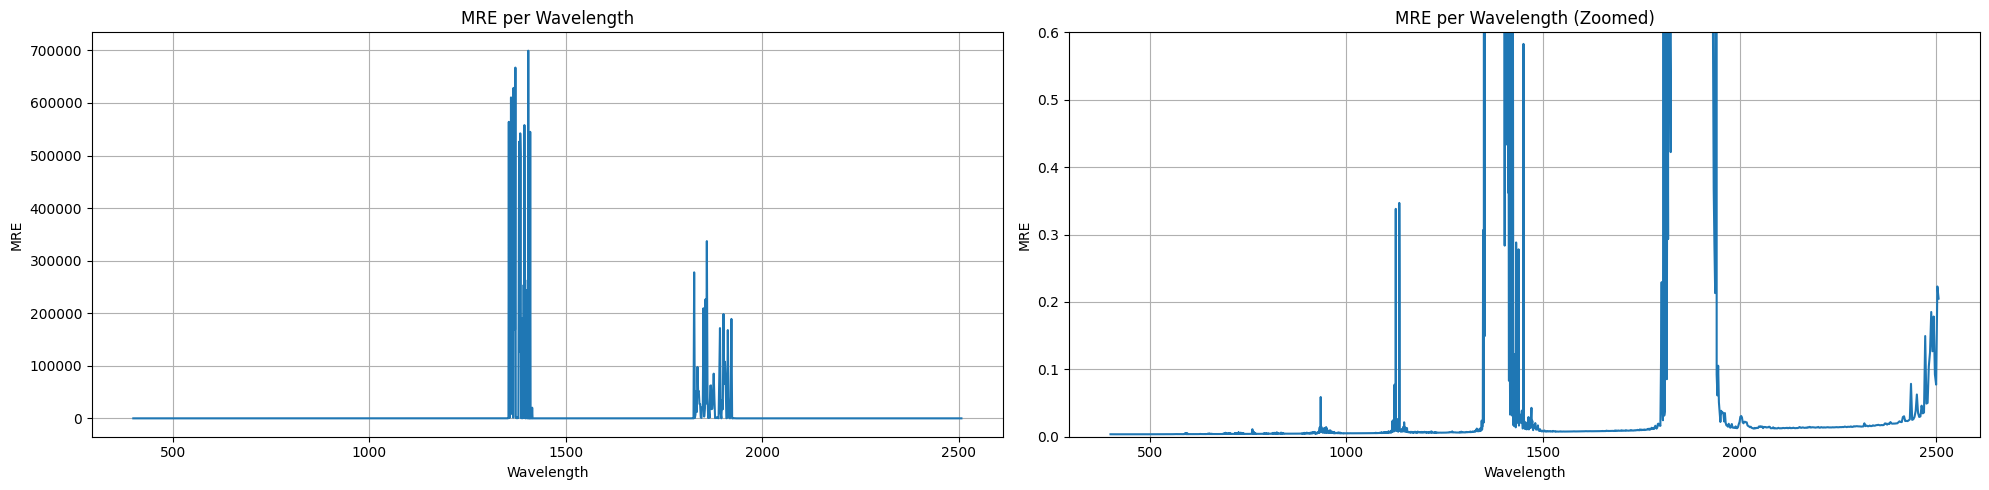

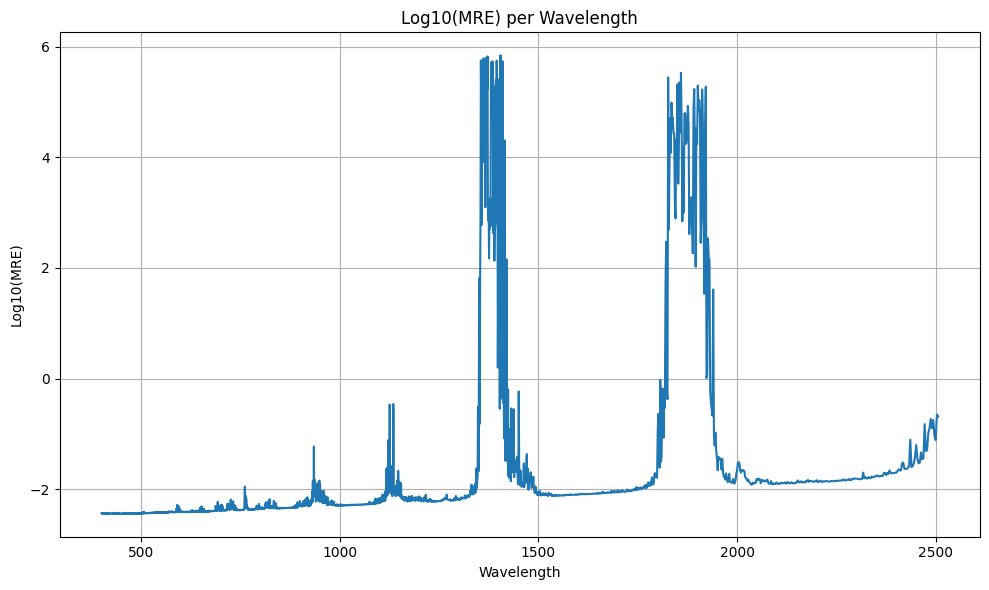

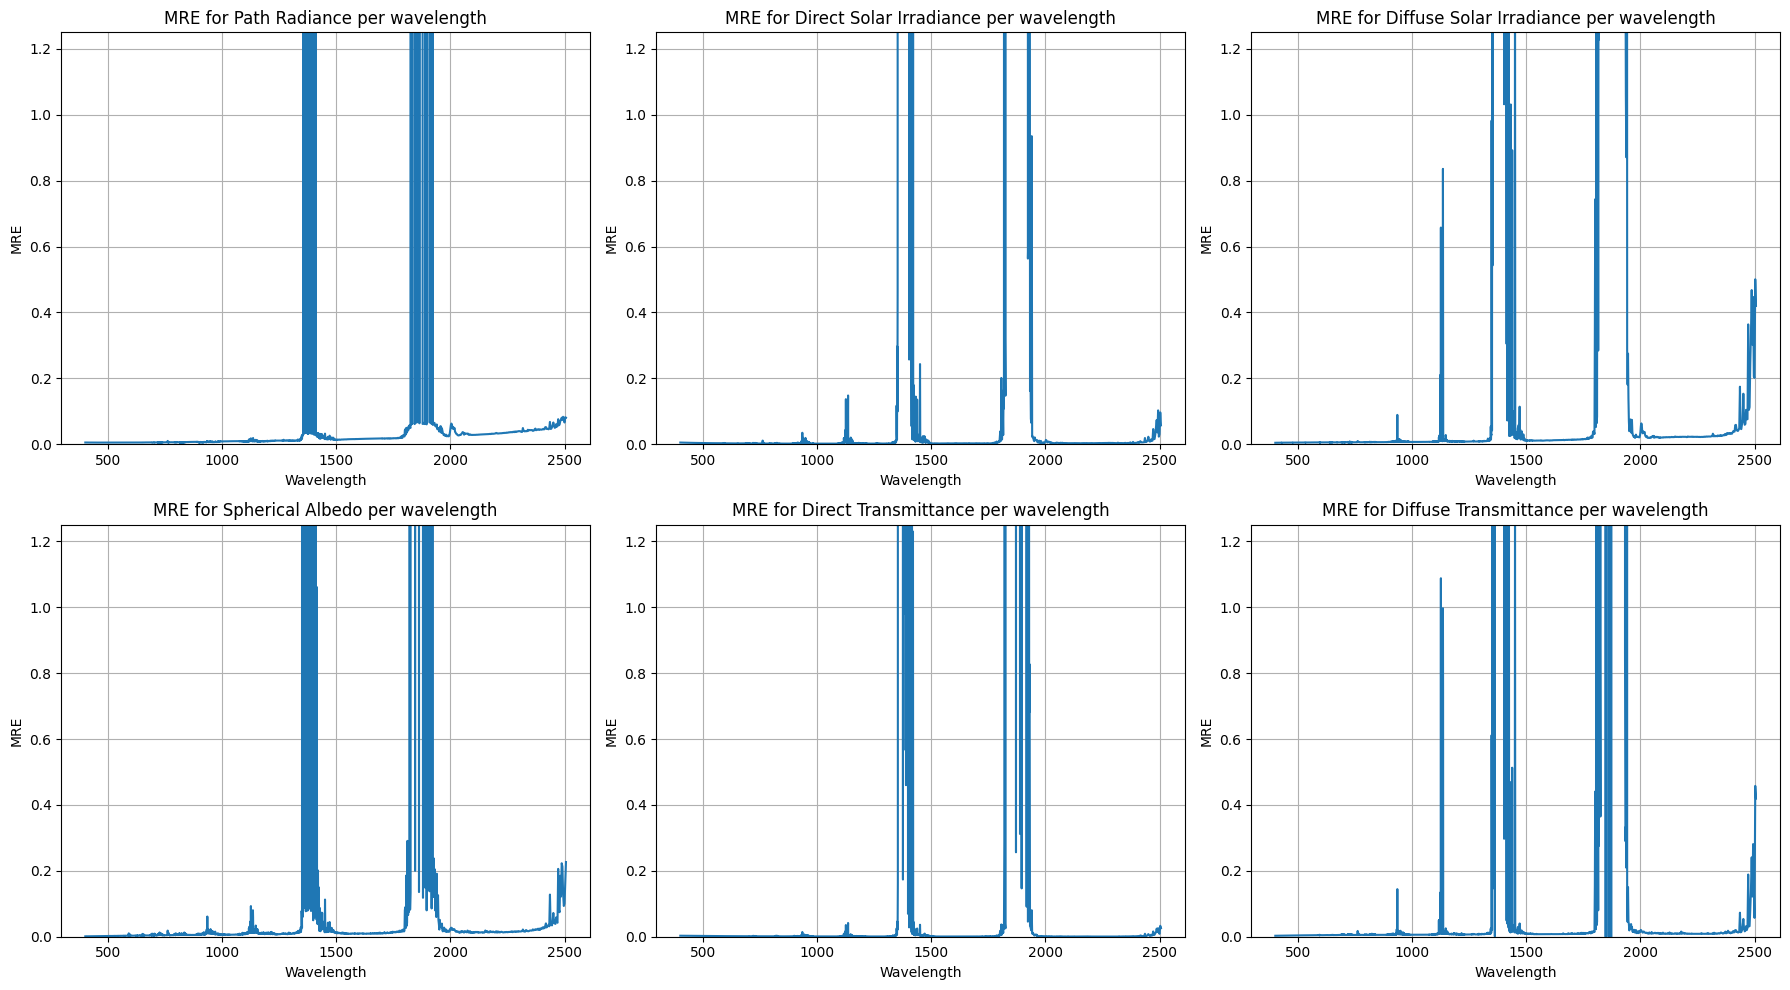

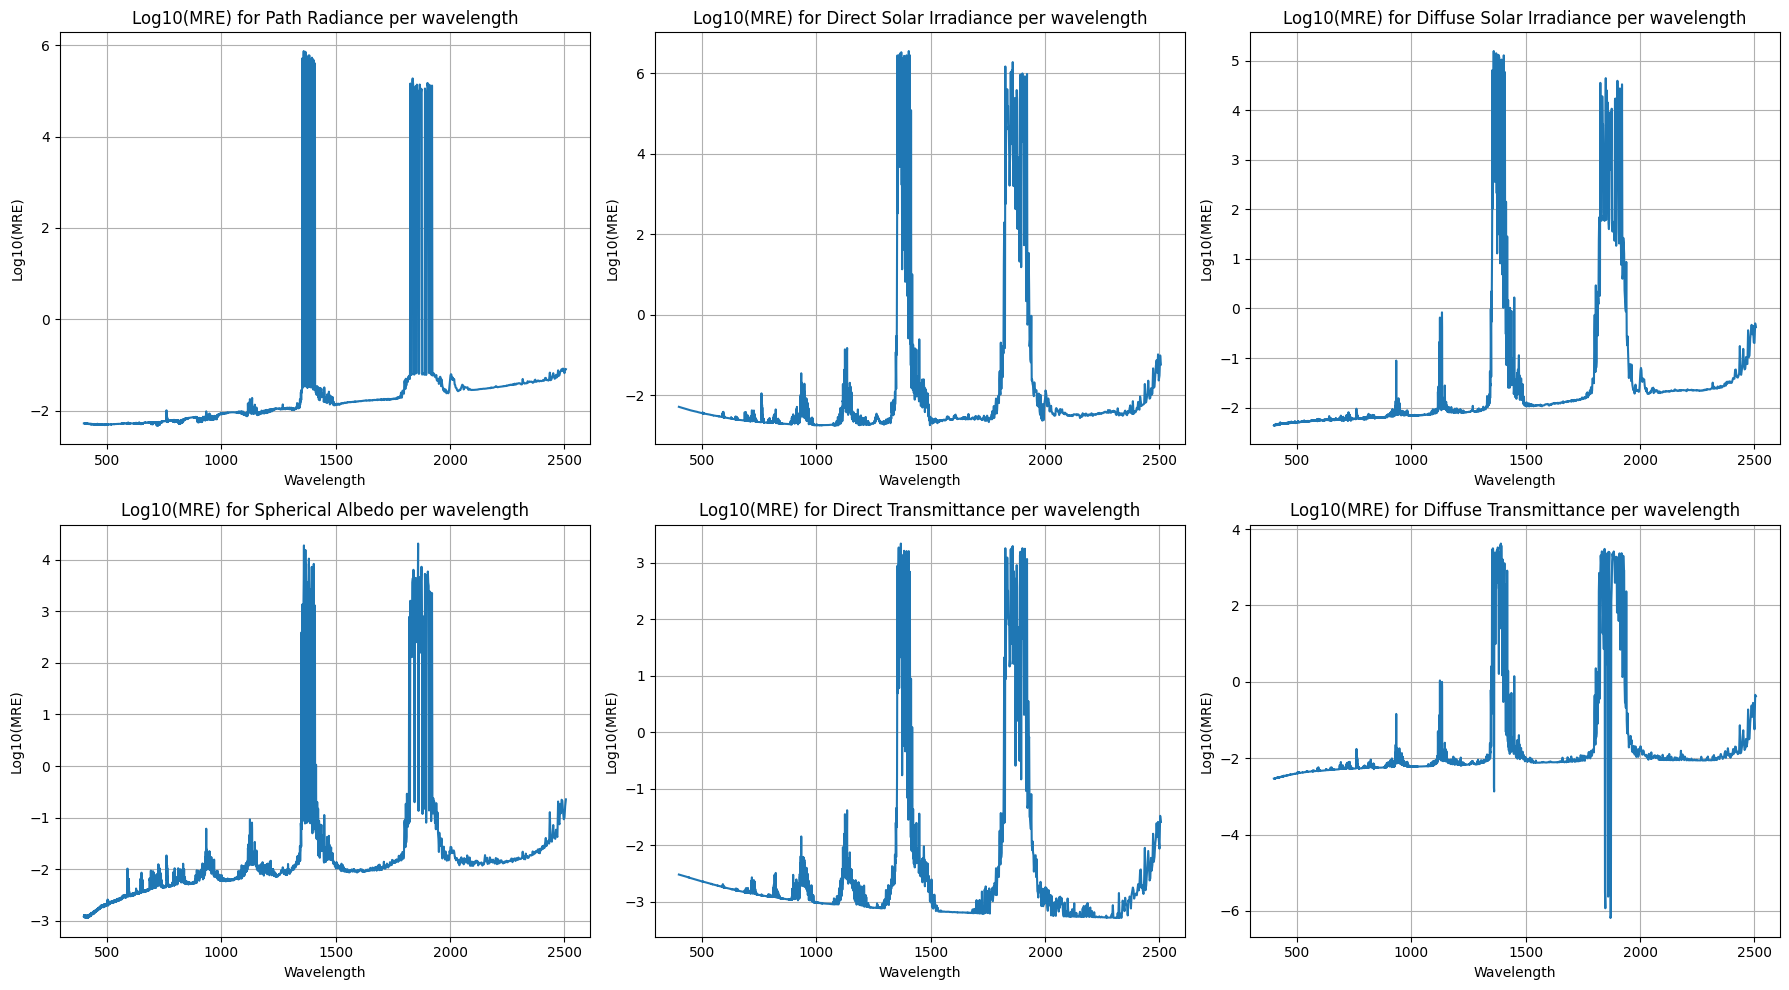

In [231]:
# predict on test set for other metrics and visualization
X_test_tensor = torch.tensor(X_test_current, dtype=torch.float32).to(device)
is_scaled  = y_scalers is not None
is_reduced = pca_list  is not None
with torch.no_grad():
    y_pred_test = model(X_test_tensor)
    if is_scaled or is_reduced:
        y_pred_og_shape = torch.zeros((y_pred_test.size(0), globals.N_FUNCTIONS, len(wavelengths)), device=y_pred_test.device)
        for i in range(globals.N_FUNCTIONS):
            y_pred_restored = y_pred_test[:, i, :].cpu().detach().numpy()
            if is_scaled:
                y_pred_restored = y_scalers[i].inverse_transform(y_pred_restored)
            if is_reduced:
                y_pred_restored = pca_list[i].inverse_transform(y_pred_restored)
            y_pred_og_shape[:, i, :] = torch.from_numpy(y_pred_restored).to(y_pred_test.device)
        y_pred_test = y_pred_og_shape

y_pred_test_np = y_pred_test.squeeze(0).cpu().numpy()

mre = utils.mre_score(Y_test, y_pred_test_np, wavelengths)
print("Testing MRE:", mre)

mre_per_func = utils.mre_score(Y_test, y_pred_test_np, wavelengths, axis=2)
for i in range(globals.N_FUNCTIONS):
    print(f"{function_names_plots[i]} MRE: {mre_per_func[i]:.4f}")

mre_per_wvl = utils.mre_score(Y_test, y_pred_test_np, wavelengths, axis=1)
fig, axes = plt.subplots(1, 2, figsize=(20, 5))
axes[0].plot(wavelengths, mre_per_wvl)
axes[0].set_xlabel("Wavelength")
axes[0].set_ylabel("MRE")
axes[0].set_title("MRE per Wavelength")
axes[0].grid()
axes[1].plot(wavelengths, mre_per_wvl)
axes[1].set_ylim(0, 0.6)
axes[1].set_xlabel("Wavelength")
axes[1].set_ylabel("MRE")
axes[1].set_title("MRE per Wavelength (Zoomed)")
axes[1].grid()
plt.tight_layout()
plt.show()

# MRE per wavelength again but in log scale to better visualize small values
mre_per_wvl_log = utils.mre_score(Y_test, y_pred_test_np, wavelengths, axis=1)
mre_per_wvl_log = np.log10(mre_per_wvl_log + 1e-10)  # add small value to avoid log(0)
plt.figure(figsize=(10, 6))
plt.plot(wavelengths, mre_per_wvl_log)
plt.xlabel("Wavelength")
plt.ylabel("Log10(MRE)")
plt.title("Log10(MRE) per Wavelength")
plt.grid()
plt.tight_layout()
plt.show()

mre_per_func_wvl = utils.mre_score(Y_test, y_pred_test_np, wavelengths, axis=0)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i in range(globals.N_FUNCTIONS):
    axes[i].plot(wavelengths, mre_per_func_wvl[i])
    axes[i].set_ylim(0, 1.25)
    axes[i].set_xlabel("Wavelength")
    axes[i].set_ylabel("MRE")
    axes[i].set_title(f"MRE for {function_names_plots[i]} per wavelength")
    axes[i].grid()
plt.tight_layout()
plt.show()

# MRE per function again but in log scale to better visualize small values
mre_per_func_wvl_log = utils.mre_score(Y_test, y_pred_test_np, wavelengths, axis=0)
mre_per_func_wvl_log = np.log10(mre_per_func_wvl_log + 1e-10)  # add small value to avoid log(0)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i in range(globals.N_FUNCTIONS):
    axes[i].plot(wavelengths, mre_per_func_wvl_log[i])
    axes[i].set_xlabel("Wavelength")
    axes[i].set_ylabel("Log10(MRE)")
    axes[i].set_title(f"Log10(MRE) for {function_names_plots[i]} per wavelength")
    axes[i].grid()
plt.tight_layout()
plt.show()

Testing MAE: 0.60167295
Path Radiance MAE: 0.1105
Direct Solar Irradiance MAE: 2.1820
Diffuse Solar Irradiance MAE: 1.3153
Spherical Albedo MAE: 0.0003
Direct Transmittance MAE: 0.0011
Diffuse Transmittance MAE: 0.0008


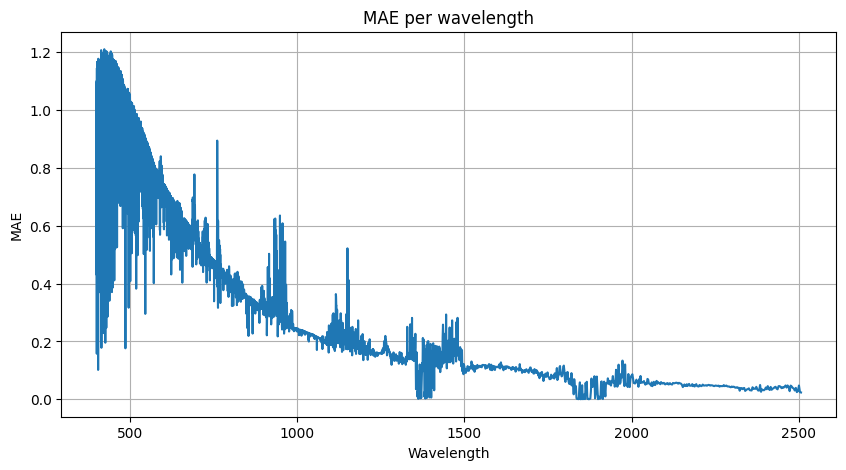

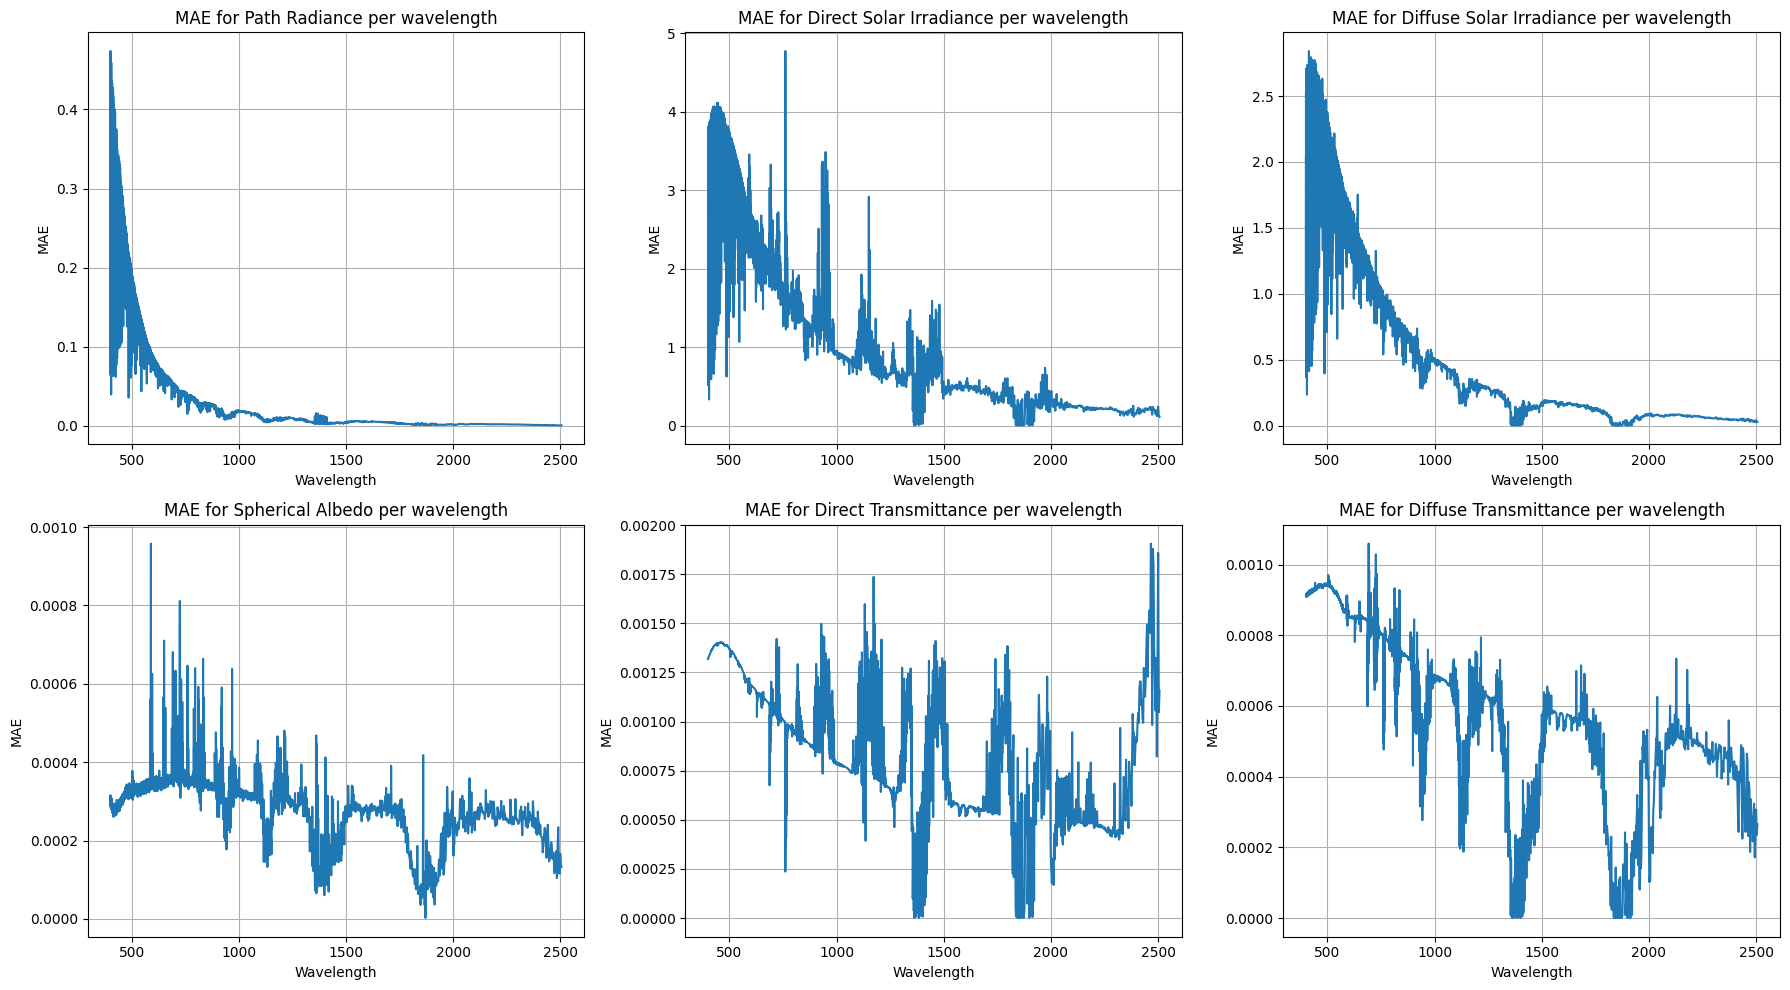

In [232]:
mae = utils.mae_score(Y_test, y_pred_test_np, wavelengths)
print("Testing MAE:", mae)

mae_per_func = utils.mae_score(Y_test, y_pred_test_np, wavelengths, axis=2)
for i in range(globals.N_FUNCTIONS):
    print(f"{function_names_plots[i]} MAE: {mae_per_func[i]:.4f}")

mae_per_wvl = utils.mae_score(Y_test, y_pred_test_np, wavelengths, axis=1)
plt.figure(figsize=(10, 5))
plt.plot(wavelengths, mae_per_wvl)
plt.xlabel("Wavelength")
plt.ylabel("MAE")
plt.title("MAE per wavelength")
plt.grid()
plt.show()

mae_per_func_wvl = utils.mae_score(Y_test, y_pred_test_np, wavelengths, axis=0)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i in range(globals.N_FUNCTIONS):
    axes[i].plot(wavelengths, mae_per_func_wvl[i])
    axes[i].set_xlabel("Wavelength")
    axes[i].set_ylabel("MAE")
    axes[i].set_title(f"MAE for {function_names_plots[i]} per wavelength")
    axes[i].grid()
plt.tight_layout()
plt.show()

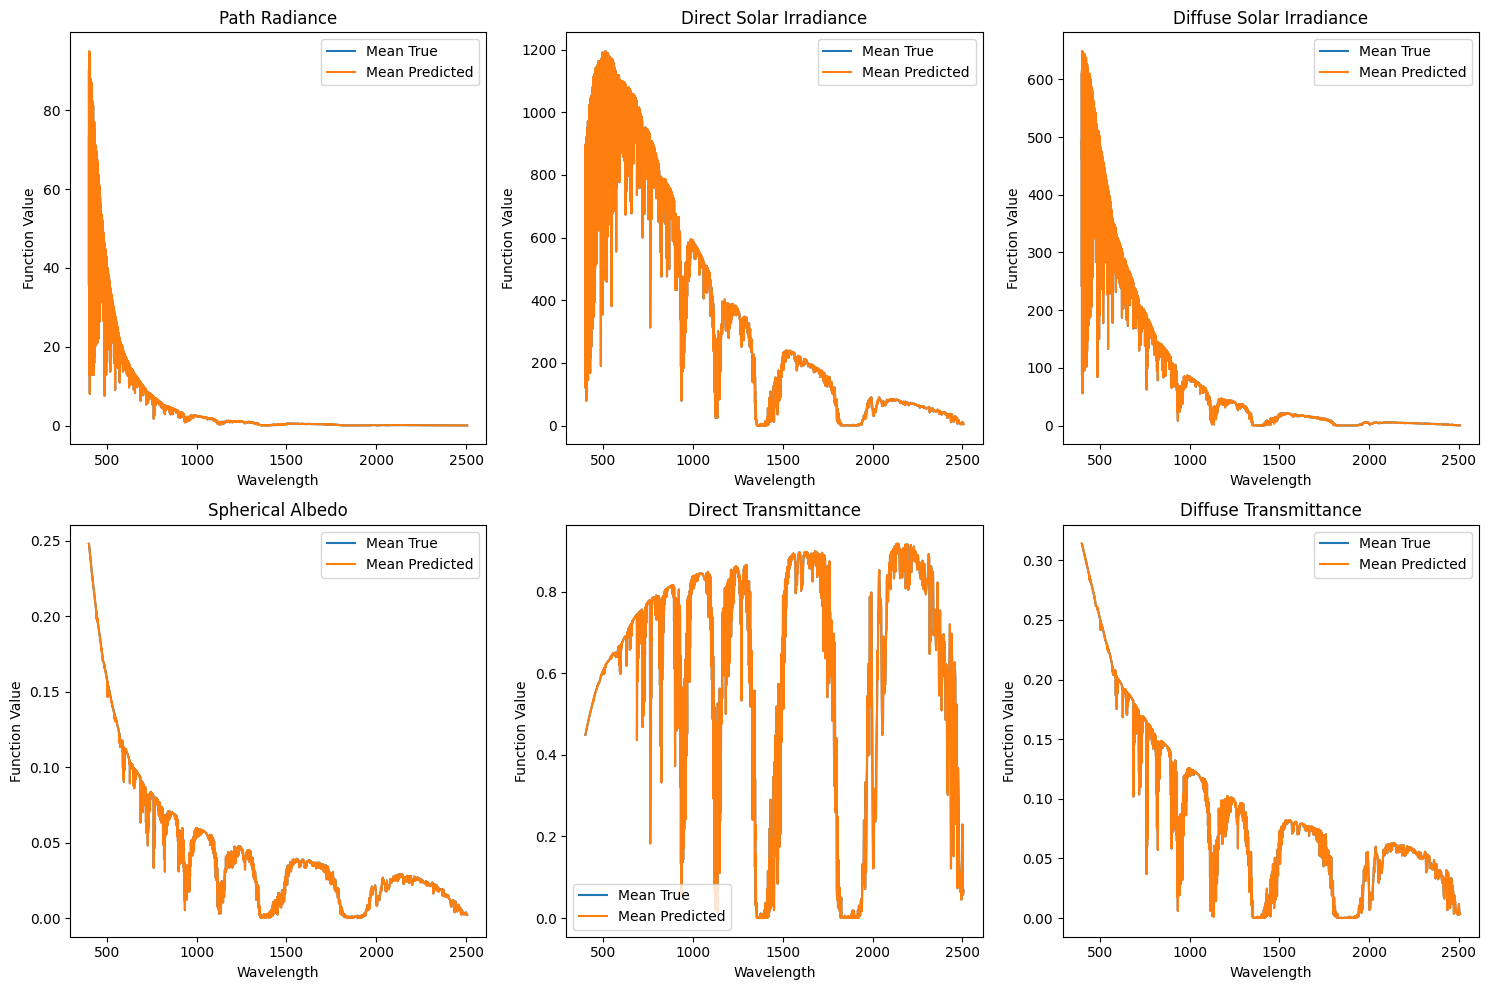

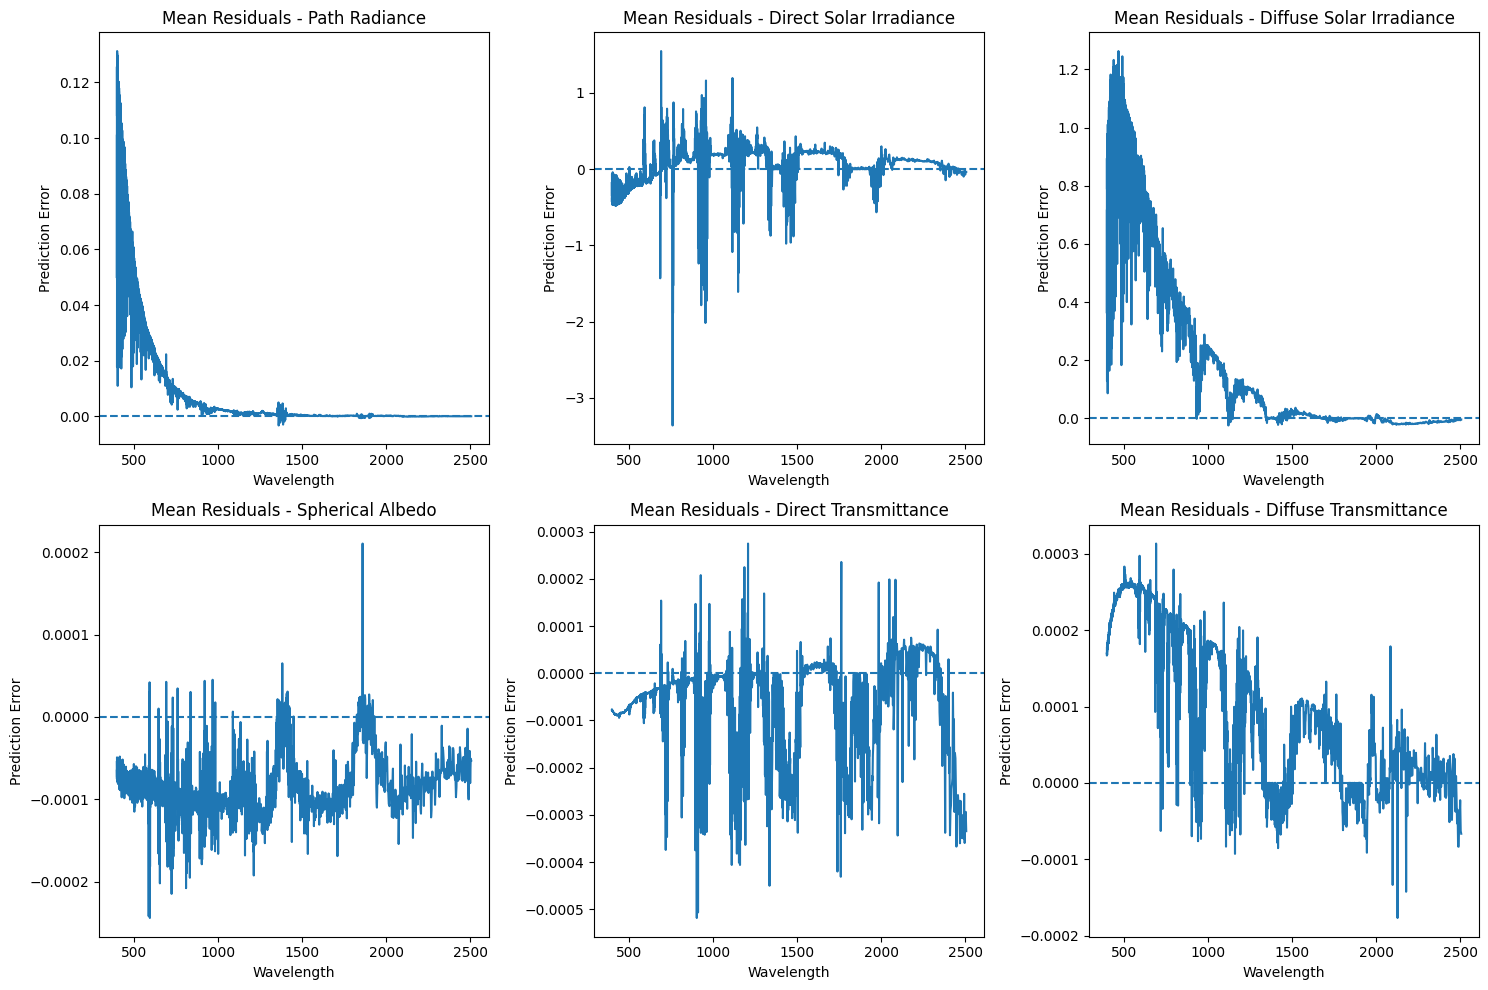

In [233]:
plt.figure(figsize=(15, 10))
for i in range(globals.N_FUNCTIONS):  # iterate over functions
    plt.subplot(2, 3, i + 1)
    plt.plot(wavelengths, np.mean(Y_test[:, i, :], axis=0), label="Mean True")
    plt.plot(wavelengths, np.mean(y_pred_test_np[:, i, :], axis=0), label="Mean Predicted")
    plt.title(f"{function_names_plots[i]}")
    plt.xlabel("Wavelength")
    plt.ylabel("Function Value")
    plt.legend()

plt.tight_layout()
plt.show()

# --- residuals for all samples ---
residuals = y_pred_test_np - Y_test

# mean residual across samples
mean_residuals = np.mean(residuals, axis=0)  # shape: (6, 4205)

plt.figure(figsize=(15, 10))

for i in range(globals.N_FUNCTIONS):
    plt.subplot(2, 3, i + 1)

    plt.plot(wavelengths, mean_residuals[i])
    plt.axhline(0, linestyle="--")

    plt.title(f"Mean Residuals - {function_names_plots[i]}")
    plt.xlabel("Wavelength")
    plt.ylabel("Prediction Error")

plt.tight_layout()
plt.show()

Load the test csv and apply the model to measure inference runtime.

In [234]:
X_test_csv = utils.load_test_csv(globals.CURRENT_TEST_FILE)
print(f"Test inputs from CSV shape: {X_test_csv.shape}")

# scale test inputs with the same scaler used for training
X_test_csv_scaled = config["x_scalers"][best_model["scale_type"]].transform(X_test_csv)

start_time_test_csv = time.time()
X_test_tensor = torch.tensor(X_test_csv_scaled, dtype=torch.float32).to(device)
with torch.no_grad():
    y_pred_test = model(X_test_tensor)
    if is_scaled or is_reduced:
        y_pred_og_shape = torch.zeros((y_pred_test.size(0), globals.N_FUNCTIONS, len(wavelengths)), device=y_pred_test.device)
        for i in range(globals.N_FUNCTIONS):
            y_pred_restored = y_pred_test[:, i, :].cpu().detach().numpy()
            if is_scaled:
                y_pred_restored = y_scalers[i].inverse_transform(y_pred_restored)
            if is_reduced:
                y_pred_restored = pca_list[i].inverse_transform(y_pred_restored)
            y_pred_og_shape[:, i, :] = torch.from_numpy(y_pred_restored).to(y_pred_test.device)
        y_pred_test = y_pred_og_shape
end_time_test_csv = time.time()

y_pred_test_np = y_pred_test.squeeze(0).cpu().numpy()

print(f"Time taken to predict on test CSV: {end_time_test_csv - start_time_test_csv:.2f} seconds")
print("Predictions on test CSV shape:", y_pred_test_np.shape)

Test inputs from CSV shape: (10000, 9)
Time taken to predict on test CSV: 0.60 seconds
Predictions on test CSV shape: (10000, 6, 4205)


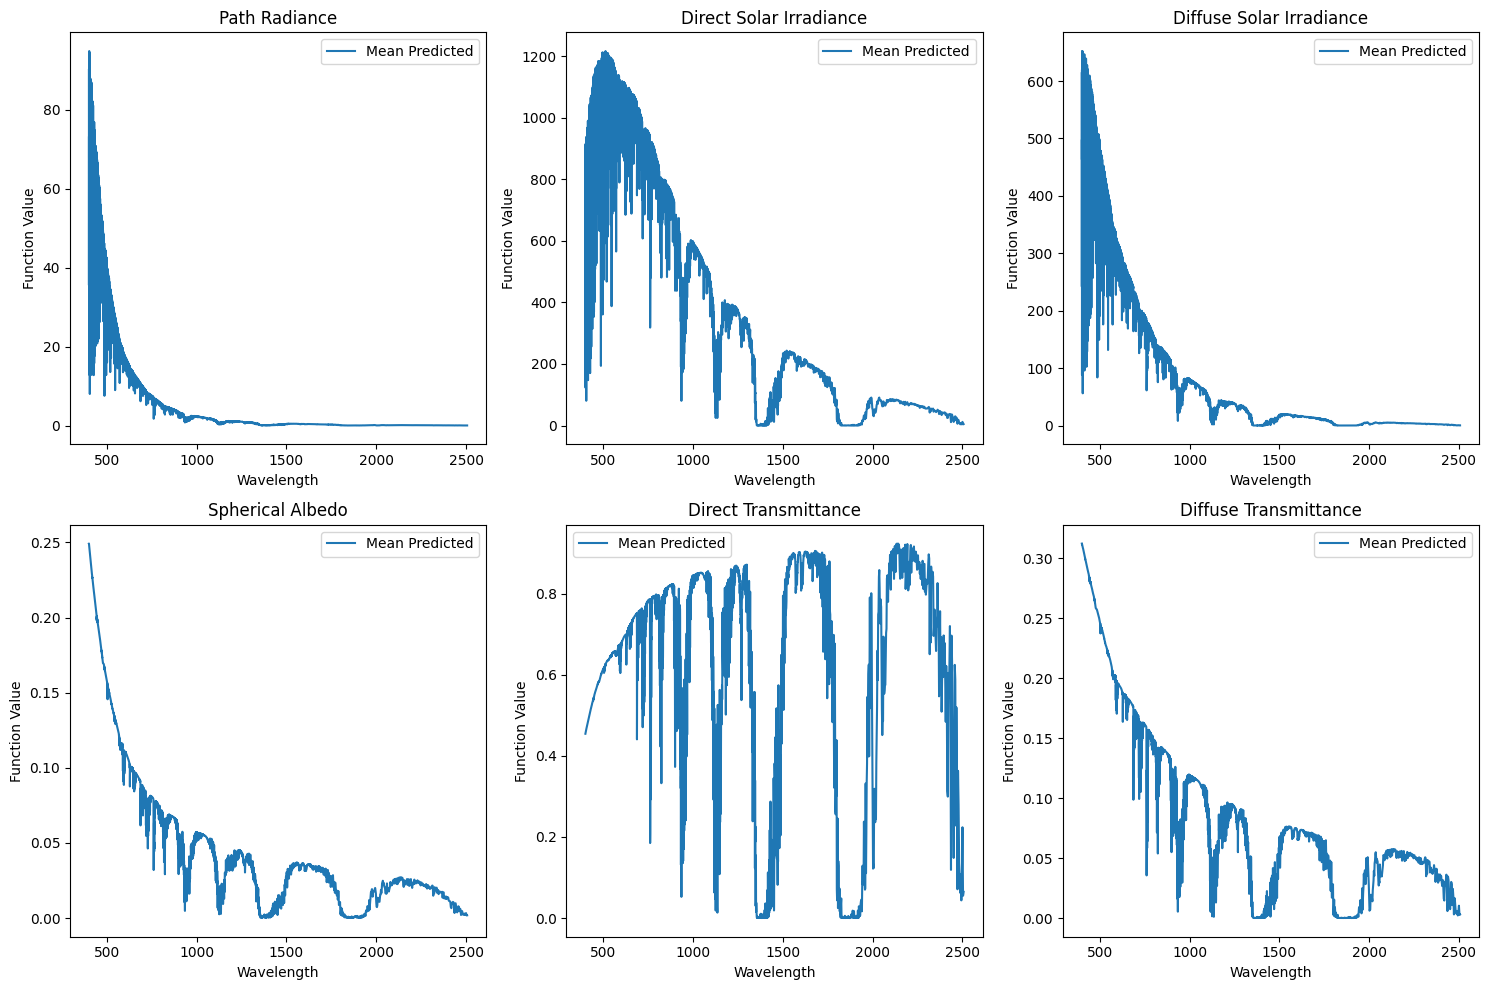

In [235]:
plt.figure(figsize=(15, 10))
for i in range(globals.N_FUNCTIONS):  # iterate over functions
    plt.subplot(2, 3, i + 1)
    plt.plot(wavelengths, np.mean(y_pred_test_np[:, i, :], axis=0), label="Mean Predicted")
    plt.title(f"{function_names_plots[i]}")
    plt.xlabel("Wavelength")
    plt.ylabel("Function Value")
    plt.legend()

plt.tight_layout()
plt.show()